In [103]:
import numpy as np
import pandas as pd

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.metrics import accuracy_score

import matplotlib.pyplot as plt

In [104]:
df = pd.read_csv("loan_data_v1.csv")

In [105]:
df

,Unnamed: 0,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,41282,31.0,female,High School,31903.0,10,OWN,13672.0,VENTURE,12.66,0.43,10.0,637.0,Yes,NaN
1,23717,29.0,female,NaN,39365.0,3,RENT,9250.0,HOMEIMPROVEMENT,15.65,0.23,7.0,625.0,No,1.0
2,39085,27.0,male,Bachelor,150854.0,6,MORTGAGE,15628.0,PERSONAL,9.18,0.10,4.0,633.0,No,0.0
3,37196,27.0,female,Bachelor,57474.0,6,RENT,5000.0,MEDICAL,10.36,0.09,7.0,NaN,Yes,0.0
4,21819,29.0,female,Associate,61039.0,7,MORTGAGE,10000.0,MEDICAL,7.88,0.16,8.0,673.0,Yes,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6995,22678,30.0,female,Associate,58445.0,11,RENT,7500.0,MEDICAL,7.49,0.13,6.0,601.0,Yes,0.0
6996,3361,22.0,male,High School,51337.0,3,RENT,11000.0,PERSONAL,11.71,0.21,2.0,651.0,No,0.0
6997,33672,24.0,male,Bachelor,83733.0,4,MORTGAGE,15000.0,EDUCATION,12.63,0.18,3.0,614.0,No,0.0
6998,25328,32.0,female,High School,31040.0,12,RENT,3000.0,PERSONAL,13.48,0.10,6.0,NaN,No,0.0


In [106]:
df.drop(columns=["Unnamed: 0"], axis=1, inplace=True)

In [107]:
df["person_gender"].unique()

array(['female', 'male', nan], dtype=object)

In [108]:
df["person_gender"] = df["person_gender"].map({"female":0,"male":1})

In [109]:
df["person_education"].unique()

array(['High School', nan, 'Bachelor', 'Associate', 'Master', 'Doctorate'],
      dtype=object)

In [110]:
from sklearn.preprocessing import OrdinalEncoder

categories = [
    'High School',
    'Associate',
    'Bachelor',
    'Master',
    'Doctorate'
]

encoder = OrdinalEncoder(categories=[categories], handle_unknown="use_encoded_value", unknown_value=np.nan)
df[["person_education"]] = encoder.fit_transform(df[['person_education']])

In [111]:
df["person_home_ownership"].unique()

array(['OWN', 'RENT', 'MORTGAGE', 'OTHER'], dtype=object)

In [112]:
df = pd.concat([df, pd.get_dummies(df["person_home_ownership"])], axis=1)
df.drop(columns=["person_home_ownership"], axis=1, inplace=True )

In [113]:
df

,person_age,person_gender,person_education,person_income,person_emp_exp,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status,MORTGAGE,OTHER,OWN,RENT
0,31.0,0.0,0.0,31903.0,10,13672.0,VENTURE,12.66,0.43,10.0,637.0,Yes,NaN,False,False,True,False
1,29.0,0.0,NaN,39365.0,3,9250.0,HOMEIMPROVEMENT,15.65,0.23,7.0,625.0,No,1.0,False,False,False,True
2,27.0,1.0,2.0,150854.0,6,15628.0,PERSONAL,9.18,0.10,4.0,633.0,No,0.0,True,False,False,False
3,27.0,0.0,2.0,57474.0,6,5000.0,MEDICAL,10.36,0.09,7.0,NaN,Yes,0.0,False,False,False,True
4,29.0,0.0,1.0,61039.0,7,10000.0,MEDICAL,7.88,0.16,8.0,673.0,Yes,0.0,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6995,30.0,0.0,1.0,58445.0,11,7500.0,MEDICAL,7.49,0.13,6.0,601.0,Yes,0.0,False,False,False,True
6996,22.0,1.0,0.0,51337.0,3,11000.0,PERSONAL,11.71,0.21,2.0,651.0,No,0.0,False,False,False,True
6997,24.0,1.0,2.0,83733.0,4,15000.0,EDUCATION,12.63,0.18,3.0,614.0,No,0.0,True,False,False,False
6998,32.0,0.0,0.0,31040.0,12,3000.0,PERSONAL,13.48,0.10,6.0,NaN,No,0.0,False,False,False,True


In [114]:
df.isnull().sum()

person_age                        402
person_gender                     268
person_education                  356
person_income                       0
person_emp_exp                      0
loan_amnt                         379
loan_intent                         0
loan_int_rate                       0
loan_percent_income                 0
cb_person_cred_hist_length          0
credit_score                      342
previous_loan_defaults_on_file      0
loan_status                       274
MORTGAGE                            0
OTHER                               0
OWN                                 0
RENT                                0
dtype: int64

In [115]:
df["loan_intent"].unique()

array(['VENTURE', 'HOMEIMPROVEMENT', 'PERSONAL', 'MEDICAL',
       'DEBTCONSOLIDATION', 'EDUCATION'], dtype=object)

In [116]:
df = pd.concat([df, pd.get_dummies(df["loan_intent"])], axis=1)
df.drop(columns=["loan_intent"], axis=1, inplace=True)

In [117]:
df.isnull().sum()

person_age                        402
person_gender                     268
person_education                  356
person_income                       0
person_emp_exp                      0
loan_amnt                         379
loan_int_rate                       0
loan_percent_income                 0
cb_person_cred_hist_length          0
credit_score                      342
previous_loan_defaults_on_file      0
loan_status                       274
MORTGAGE                            0
OTHER                               0
OWN                                 0
RENT                                0
DEBTCONSOLIDATION                   0
EDUCATION                           0
HOMEIMPROVEMENT                     0
MEDICAL                             0
PERSONAL                            0
VENTURE                             0
dtype: int64

In [118]:
df["person_age"] = df["person_age"].fillna(df["person_age"].median())

In [119]:
df["person_gender"] = df["person_gender"].fillna(df["person_gender"].mode()[0])

In [120]:
df["person_education"] = df["person_education"].fillna(df["person_education"].mode()[0])

In [121]:
df

,person_age,person_gender,person_education,person_income,person_emp_exp,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,...,MORTGAGE,OTHER,OWN,RENT,DEBTCONSOLIDATION,EDUCATION,HOMEIMPROVEMENT,MEDICAL,PERSONAL,VENTURE
0,31.0,0.0,0.0,31903.0,10,13672.0,12.66,0.43,10.0,637.0,...,False,False,True,False,False,False,False,False,False,True
1,29.0,0.0,2.0,39365.0,3,9250.0,15.65,0.23,7.0,625.0,...,False,False,False,True,False,False,True,False,False,False
2,27.0,1.0,2.0,150854.0,6,15628.0,9.18,0.10,4.0,633.0,...,True,False,False,False,False,False,False,False,True,False
3,27.0,0.0,2.0,57474.0,6,5000.0,10.36,0.09,7.0,NaN,...,False,False,False,True,False,False,False,True,False,False
4,29.0,0.0,1.0,61039.0,7,10000.0,7.88,0.16,8.0,673.0,...,True,False,False,False,False,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6995,30.0,0.0,1.0,58445.0,11,7500.0,7.49,0.13,6.0,601.0,...,False,False,False,True,False,False,False,True,False,False
6996,22.0,1.0,0.0,51337.0,3,11000.0,11.71,0.21,2.0,651.0,...,False,False,False,True,False,False,False,False,True,False
6997,24.0,1.0,2.0,83733.0,4,15000.0,12.63,0.18,3.0,614.0,...,True,False,False,False,False,True,False,False,False,False
6998,32.0,0.0,0.0,31040.0,12,3000.0,13.48,0.10,6.0,NaN,...,False,False,False,True,False,False,False,False,True,False


<Axes: ylabel='Frequency'>

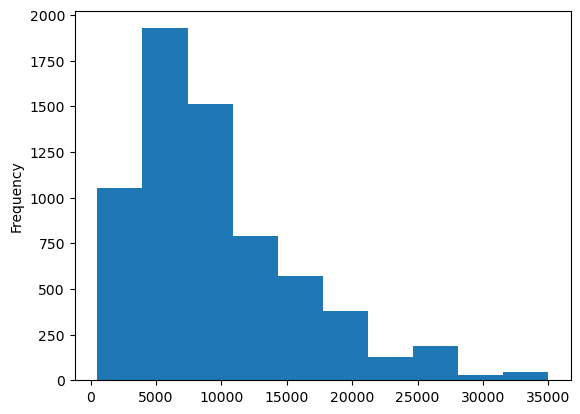

In [122]:
df["loan_amnt"].plot.hist()

In [123]:
df["loan_amnt"] = df["loan_amnt"].fillna(df["loan_amnt"].median())

<Axes: ylabel='Frequency'>

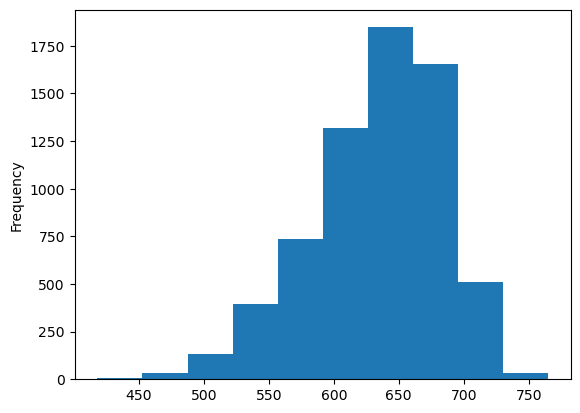

In [124]:
df["credit_score"].plot.hist()

In [125]:
df["credit_score"] = df["credit_score"].fillna(df["credit_score"].median())

In [126]:
df.isnull().sum()

person_age                          0
person_gender                       0
person_education                    0
person_income                       0
person_emp_exp                      0
loan_amnt                           0
loan_int_rate                       0
loan_percent_income                 0
cb_person_cred_hist_length          0
credit_score                        0
previous_loan_defaults_on_file      0
loan_status                       274
MORTGAGE                            0
OTHER                               0
OWN                                 0
RENT                                0
DEBTCONSOLIDATION                   0
EDUCATION                           0
HOMEIMPROVEMENT                     0
MEDICAL                             0
PERSONAL                            0
VENTURE                             0
dtype: int64

In [127]:
df["loan_status"]

0       NaN
1       1.0
2       0.0
3       0.0
4       0.0
       ... 
6995    0.0
6996    0.0
6997    0.0
6998    0.0
6999    0.0
Name: loan_status, Length: 7000, dtype: float64

In [128]:
df["loan_status"].unique()

array([nan,  1.,  0.])

In [129]:
df.dropna(subset=["loan_status"], axis=0, inplace=True)

In [130]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6726 entries, 1 to 6999
Data columns (total 22 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   person_age                      6726 non-null   float64
 1   person_gender                   6726 non-null   float64
 2   person_education                6726 non-null   float64
 3   person_income                   6726 non-null   float64
 4   person_emp_exp                  6726 non-null   int64  
 5   loan_amnt                       6726 non-null   float64
 6   loan_int_rate                   6726 non-null   float64
 7   loan_percent_income             6726 non-null   float64
 8   cb_person_cred_hist_length      6726 non-null   float64
 9   credit_score                    6726 non-null   float64
 10  previous_loan_defaults_on_file  6726 non-null   object 
 11  loan_status                     6726 non-null   float64
 12  MORTGAGE                        6726 no

In [131]:
df["previous_loan_defaults_on_file"].unique()

array(['No', 'Yes'], dtype=object)

In [132]:
df["previous_loan_defaults_on_file"] = df["previous_loan_defaults_on_file"].map({"No":0,"Yes":1})

In [133]:
X, y = df.drop(columns=["loan_status"]), df["loan_status"]

In [134]:
df.isna().sum()

person_age                        0
person_gender                     0
person_education                  0
person_income                     0
person_emp_exp                    0
loan_amnt                         0
loan_int_rate                     0
loan_percent_income               0
cb_person_cred_hist_length        0
credit_score                      0
previous_loan_defaults_on_file    0
loan_status                       0
MORTGAGE                          0
OTHER                             0
OWN                               0
RENT                              0
DEBTCONSOLIDATION                 0
EDUCATION                         0
HOMEIMPROVEMENT                   0
MEDICAL                           0
PERSONAL                          0
VENTURE                           0
dtype: int64

<Axes: >

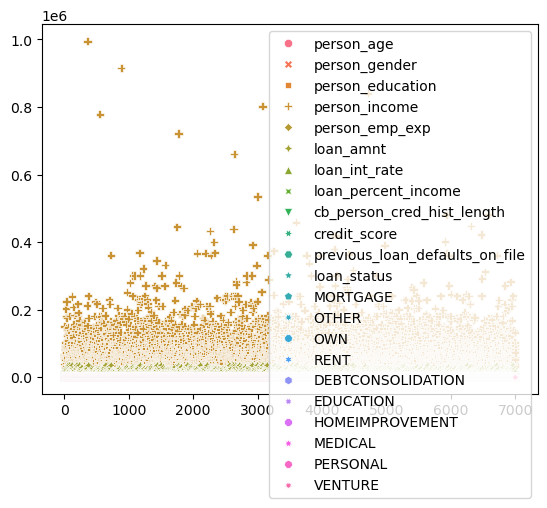

In [135]:
import seaborn as sns
sns.scatterplot(df)

In [136]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LogisticRegression

scaler = MinMaxScaler()
train_X, test_X, train_y, test_y = train_test_split(X,y,test_size=0.2,random_state=42)
train_X = scaler.fit_transform(train_X)
test_X = scaler.transform(test_X)
classifier = LogisticRegression().fit(train_X, train_y)

pred_y = classifier.predict(test_X)

In [138]:
from sklearn.metrics import classification_report

print(classification_report(test_y, pred_y))

              precision    recall  f1-score   support

         0.0       0.91      0.96      0.94      1020
         1.0       0.84      0.72      0.78       326

    accuracy                           0.90      1346
   macro avg       0.88      0.84      0.86      1346
weighted avg       0.90      0.90      0.90      1346

